# Fine-tuning Qwen2.5-7B-Instruct for Named Entity Recognition

Run on **Google Colab** with a GPU runtime (T4 or A100 recommended).

## Experiment Grid

| Category | Configs |
|---|---|
| Baselines | Zero-shot, Few-shot (5 in-context examples) |
| Generic only | 0.5k, 1k, 2k, 4k samples |
| Domain (tech) only | 0.5k, 1k, 2k, 4k samples |
| Generic → Domain | 0.5k+0.5k, 1k+1k, 2k+2k, 4k+4k (two-phase sequential SFT) |

**Dataset:** [NuNER](https://huggingface.co/datasets/numind/NuNER) — preprocessed by `preprocessing.ipynb`
**Metric:** Entity-level micro F1 (exact match on entity text + type, case-insensitive)


In [1]:
%%capture
# Install Unsloth (pulls in transformers, peft, trl, bitsandbytes, etc.)
!pip install unsloth

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import ast, gc, json, re, warnings
from pathlib import Path

import pandas as pd
import torch
from datasets import Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


PyTorch  : 2.10.0+cu128
CUDA     : True
GPU      : NVIDIA A100-SXM4-80GB
VRAM     : 85.1 GB


In [4]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Configuration — edit as needed ───────────────────────────────────────────
MODEL_NAME    = "unsloth/Qwen2.5-7B-Instruct"
DATA_DIR      = Path("/content/drive/MyDrive/stat359/data")
RESULTS_CSV   = Path("/content/drive/MyDrive/stat359/results_qwen25_7b.csv")

# System prompt — NuNER inputs are raw text with no task instruction;
# this prompt provides the annotation guideline from the NuNER paper.
SYSTEM_PROMPT = (
    "You are a named entity recognition expert. "
    "Label as many entities, concepts, and ideas as possible in the input text. "
    "Return a Python list where each entry follows the format 'entity text <> entity type'. "
    "Output only the list."
)

# LoRA
MAX_SEQ_LEN   = 2048
LORA_R        = 16
LORA_ALPHA    = 32
LORA_DROPOUT  = 0.05

# Training
TRAIN_EPOCHS  = 1           # epochs per training phase
LEARNING_RATE = 2e-4
BATCH_SIZE    = 2
GRAD_ACCUM    = 4           # effective batch size = BATCH_SIZE * GRAD_ACCUM = 8

# Evaluation
EVAL_SAMPLE   = 500         # max test samples; set None to evaluate on full test set
FEW_SHOT_N    = 5           # in-context examples for the few-shot baseline
SEED          = 42

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ── Data utilities ────────────────────────────────────────────────────────────

def parse_entity_set(output_str: str) -> set:
    """Parse a NuNER output string into a set of (entity_text, entity_type) tuples."""
    match = re.search(r'\[.*?\]', str(output_str), re.DOTALL)
    if not match:
        return set()
    try:
        items = ast.literal_eval(match.group())
    except (ValueError, SyntaxError):
        return set()
    result = set()
    for item in items:
        if isinstance(item, str) and ' <> ' in item:
            parts = item.split(' <> ', maxsplit=1)
            if len(parts) == 2:
                result.add((parts[0].strip().lower(), parts[1].strip().lower()))
    return result


def entity_f1(predictions: list, ground_truths: list) -> dict:
    """Compute entity-level micro Precision / Recall / F1."""
    tp = fp = fn = 0
    for pred_str, gt_str in zip(predictions, ground_truths):
        pred_set = parse_entity_set(pred_str)
        gt_set   = parse_entity_set(gt_str)
        tp += len(pred_set & gt_set)
        fp += len(pred_set - gt_set)
        fn += len(gt_set  - pred_set)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    return {
        "precision": round(precision, 4),
        "recall":    round(recall,    4),
        "f1":        round(f1,        4),
        "tp": tp, "fp": fp, "fn": fn,
    }


def format_chat(input_text: str, output_text: str, tokenizer) -> str:
    """Format a NuNER sample as a chat turn for SFT (uses the model's chat template)."""
    messages = [
        {"role": "system",    "content": SYSTEM_PROMPT},
        {"role": "user",      "content": input_text},
        {"role": "assistant", "content": output_text},
    ]
    return tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )


def generate_response(
    model, tokenizer, input_text: str,
    few_shot_examples: list | None = None,
    max_new_tokens: int = 256,
) -> str:
    """Run inference and return the raw text output (stripped)."""
    messages = [{"role": "system", "content": SYSTEM_PROMPT}]
    for ex in (few_shot_examples or []):
        messages.append({"role": "user",      "content": ex["input"]})
        messages.append({"role": "assistant", "content": ex["output"]})
    messages.append({"role": "user", "content": input_text})

    encoded = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    )
    # Transformers ≥5.x returns BatchEncoding; extract input_ids tensor
    input_ids = encoded["input_ids"].to(model.device) if hasattr(encoded, "keys") else encoded.to(model.device)

    with torch.inference_mode():
        output_ids = model.generate(
            input_ids,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )
    new_tokens = output_ids[0][input_ids.shape[1]:]
    return tokenizer.decode(new_tokens, skip_special_tokens=True).strip()


print("Utilities loaded.")

Utilities loaded.


In [6]:
# ── Load preprocessed data ────────────────────────────────────────────────────
# Run preprocessing.ipynb first to generate these files.

generic_train = pd.read_parquet(DATA_DIR / "generic_train.parquet")
domain_train  = pd.read_parquet(DATA_DIR / "domain_train.parquet")
test_df       = pd.read_parquet(DATA_DIR / "test.parquet")

# Optional: subsample test set for faster evaluation
if EVAL_SAMPLE and len(test_df) > EVAL_SAMPLE:
    test_eval = test_df.sample(EVAL_SAMPLE, random_state=SEED).reset_index(drop=True)
else:
    test_eval = test_df.reset_index(drop=True)

# Fixed few-shot examples drawn from generic training set
few_shot_examples = (
    generic_train.sample(FEW_SHOT_N, random_state=SEED)[["input", "output"]]
    .to_dict("records")
)

print(f"Generic train : {len(generic_train):,} samples")
print(f"Domain train  : {len(domain_train):,} samples")
print(f"Test (eval)   : {len(test_eval):,} / {len(test_df):,} total")
print(f"Few-shot exs  : {len(few_shot_examples)}")


Generic train : 5,000 samples
Domain train  : 5,000 samples
Test (eval)   : 400 / 400 total
Few-shot exs  : 5


In [7]:
# ── Model loading and LoRA setup ──────────────────────────────────────────────
from unsloth import FastLanguageModel, is_bfloat16_supported


def load_model_with_lora():
    """Load the base model with Unsloth QLoRA and apply LoRA adapters."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LEN,
        dtype=None,         # auto-detect (bf16 on Ampere+, fp16 on T4)
        load_in_4bit=True,  # QLoRA 4-bit quantisation
    )
    model = FastLanguageModel.get_peft_model(
        model,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        target_modules=[
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj",
        ],
        lora_dropout=LORA_DROPOUT,
        bias="none",
        use_gradient_checkpointing="unsloth",  # saves VRAM
        random_state=SEED,
    )
    return model, tokenizer


def free_memory(model=None):
    """Release GPU memory between experiments."""
    if model is not None:
        del model
    gc.collect()
    torch.cuda.empty_cache()
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated() / 1e9
        total = torch.cuda.get_device_properties(0).total_memory / 1e9
        print(f"VRAM used after cleanup: {used:.2f} / {total:.1f} GB")


print("Model utilities defined.")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Model utilities defined.


In [8]:
# ── Training utilities ────────────────────────────────────────────────────────
from trl import SFTTrainer, SFTConfig


def make_hf_dataset(df: pd.DataFrame, tokenizer) -> Dataset:
    """Convert a DataFrame to a HuggingFace Dataset in SFT chat-template format."""
    records = [
        {"text": format_chat(row["input"], row["output"], tokenizer)}
        for _, row in df.iterrows()
    ]
    return Dataset.from_list(records)


def train_on_dataset(model, tokenizer, df: pd.DataFrame, run_dir: str = "./tmp") -> object:
    """Run one phase of SFT; returns the trained model (in-memory, same object)."""
    dataset = make_hf_dataset(df, tokenizer)
    trainer = SFTTrainer(
        model=model,
        tokenizer=tokenizer,
        train_dataset=dataset,
        args=SFTConfig(
            output_dir=run_dir,
            num_train_epochs=TRAIN_EPOCHS,
            per_device_train_batch_size=BATCH_SIZE,
            gradient_accumulation_steps=GRAD_ACCUM,
            warmup_ratio=0.05,
            learning_rate=LEARNING_RATE,
            fp16=not is_bfloat16_supported(),
            bf16=is_bfloat16_supported(),
            logging_steps=25,
            save_strategy="no",
            report_to="none",
            lr_scheduler_type="cosine",
            optim="adamw_8bit",
            max_seq_length=MAX_SEQ_LEN,
            dataset_text_field="text",
            seed=SEED,
        ),
    )
    trainer.train()
    return model


print("Training utilities defined.")


Training utilities defined.


In [9]:
# ── Evaluation utilities ──────────────────────────────────────────────────────

def evaluate_model(
    model, tokenizer, eval_df: pd.DataFrame,
    few_shot_examples=None, desc: str = "Evaluating",
) -> dict:
    """Switch model to inference mode, run predictions, return entity F1 metrics."""
    FastLanguageModel.for_inference(model)
    predictions  = []
    ground_truths = list(eval_df["output"])

    for _, row in tqdm(eval_df.iterrows(), total=len(eval_df), desc=desc):
        pred = generate_response(
            model, tokenizer, row["input"], few_shot_examples=few_shot_examples
        )
        predictions.append(pred)

    metrics = entity_f1(predictions, ground_truths)
    print(
        f"  P={metrics['precision']:.4f}  "
        f"R={metrics['recall']:.4f}  "
        f"F1={metrics['f1']:.4f}  "
        f"(TP={metrics['tp']} FP={metrics['fp']} FN={metrics['fn']})"
    )
    return metrics


def save_result(row: dict):
    """Append one result dict to the cumulative results CSV."""
    df_new = pd.DataFrame([row])
    if RESULTS_CSV.exists():
        df_old = pd.read_csv(RESULTS_CSV)
        df_new = pd.concat([df_old, df_new], ignore_index=True)
    df_new.to_csv(RESULTS_CSV, index=False)
    print(f"  Saved → {RESULTS_CSV}")


print("Evaluation utilities defined.")


Evaluation utilities defined.


## Baselines

Evaluate the model without any fine-tuning.

In [10]:
# ── Baseline 1: Zero-shot ─────────────────────────────────────────────────────
print("Loading model for zero-shot baseline...")
model, tokenizer = load_model_with_lora()

print("\nRunning zero-shot evaluation...")
metrics = evaluate_model(model, tokenizer, test_eval, desc="Zero-shot")
save_result({
    "experiment": "zero_shot", "description": "Zero-shot",
    "generic_n": 0, "domain_n": 0, "sequential": False, **metrics,
})
free_memory(model)


Loading model for zero-shot baseline...
==((====))==  Unsloth 2026.3.3: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

...

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.
Unsloth 2026.3.3 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.



Running zero-shot evaluation...


Zero-shot:   0%|          | 0/400 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
--- Logging error ---
Traceback (most recent call last):
  File "/usr/lib/python3.12/logging/__init__.py", line 1160, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 999, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 703, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/logging/__init__.py", line 392, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_c

  P=0.1944  R=0.0037  F1=0.0073  (TP=7 FP=29 FN=1884)
  Saved → /content/drive/MyDrive/stat359/results_qwen25_7b.csv
VRAM used after cleanup: 7.48 / 85.1 GB


In [11]:
# ── Baseline 2: Few-shot (5-shot, no fine-tuning) ─────────────────────────────
print("Loading model for few-shot baseline...")
model, tokenizer = load_model_with_lora()

print(f"\nRunning {FEW_SHOT_N}-shot evaluation...")
metrics = evaluate_model(
    model, tokenizer, test_eval,
    few_shot_examples=few_shot_examples,
    desc=f"Few-shot ({FEW_SHOT_N})",
)
save_result({
    "experiment": "few_shot", "description": f"Few-shot ({FEW_SHOT_N}-shot)",
    "generic_n": 0, "domain_n": 0, "sequential": False, **metrics,
})
free_memory(model)


Loading model for few-shot baseline...
==((====))==  Unsloth 2026.3.3: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

unsloth/qwen2.5-7b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.

Running 5-shot evaluation...


Few-shot (5):   0%|          | 0/400 [00:00<?, ?it/s]

  P=0.2163  R=0.1920  F1=0.2034  (TP=363 FP=1315 FN=1528)
  Saved → /content/drive/MyDrive/stat359/results_qwen25_7b.csv
VRAM used after cleanup: 7.50 / 85.1 GB


## Fine-tuning Experiments

Each experiment reloads the base model from scratch for a clean comparison.
Sequential configs (`Generic→Domain`) run two consecutive training phases on the **same model object** — generic first, domain second.

Results are written to the CSV after each run so interrupted sessions resume automatically.

In [14]:
# ── Fine-tuning experiment definitions ────────────────────────────────────────
# (name, description, generic_n, domain_n, sequential)
EXPERIMENTS = [
    ("generic_500",  "Generic 0.5k",             500,   0,    False),
    ("generic_1k",   "Generic 1k",               1000,  0,    False),
    ("generic_2k",   "Generic 2k",               2000,  0,    False),
    ("generic_4k",   "Generic 4k",               4000,  0,    False),
    ("domain_500",   "Domain 0.5k",               0,   500,   False),
    ("domain_1k",    "Domain 1k",                 0,  1000,   False),
    ("domain_2k",    "Domain 2k",                 0,  2000,   False),
    ("domain_4k",    "Domain 4k",                 0,  4000,   False),
    ("seq_500_500",  "Generic→Domain 0.5k+0.5k",  500,  500,  True),
    ("seq_1k_1k",    "Generic→Domain 1k+1k",     1000, 1000,  True),
    ("seq_2k_2k",    "Generic→Domain 2k+2k",     2000, 2000,  True),
]


def run_experiment(name, description, generic_n, domain_n, sequential):
    """
    Run a single SFT experiment:
    - Reloads base model from scratch for a clean comparison.
    - Sequential configs fine-tune on generic first, then domain (same model object).
    - Mixed configs (both > 0, sequential=False) concatenate and shuffle.
    - Results are appended to RESULTS_CSV after each experiment.
    """
    print(f"\n{'='*60}")
    print(f"  {description}")
    print(f"{'='*60}")

    model, tokenizer = load_model_with_lora()

    if sequential:
        # Phase 1 — generic
        if generic_n > 0:
            g_df = generic_train.sample(
                min(generic_n, len(generic_train)), random_state=SEED
            )
            print(f"Phase 1 — {len(g_df):,} generic samples")
            model = train_on_dataset(model, tokenizer, g_df, run_dir=f"./runs/{name}_p1")

        # Phase 2 — domain (continues from phase-1 weights)
        if domain_n > 0:
            d_df = domain_train.sample(
                min(domain_n, len(domain_train)), random_state=SEED
            )
            print(f"Phase 2 — {len(d_df):,} domain samples")
            model = train_on_dataset(model, tokenizer, d_df, run_dir=f"./runs/{name}_p2")
    else:
        if generic_n > 0 and domain_n > 0:
            # Mixed: combine generic + domain and shuffle
            g_df = generic_train.sample(min(generic_n, len(generic_train)), random_state=SEED)
            d_df = domain_train.sample(min(domain_n, len(domain_train)), random_state=SEED)
            df = pd.concat([g_df, d_df]).sample(frac=1, random_state=SEED).reset_index(drop=True)
        elif generic_n > 0:
            df = generic_train.sample(min(generic_n, len(generic_train)), random_state=SEED)
        else:
            df = domain_train.sample(min(domain_n, len(domain_train)), random_state=SEED)
        print(f"Training on {len(df):,} samples")
        model = train_on_dataset(model, tokenizer, df, run_dir=f"./runs/{name}")

    metrics = evaluate_model(model, tokenizer, test_eval, desc=f"Eval [{description}]")
    save_result({
        "experiment": name, "description": description,
        "generic_n": generic_n, "domain_n": domain_n, "sequential": sequential,
        **metrics,
    })
    free_memory(model)
    return metrics


print(f"Experiment runner defined. Total SFT configs: {len(EXPERIMENTS)}")

Experiment runner defined. Total SFT configs: 11


In [13]:
# ── Run all fine-tuning experiments ──────────────────────────────────────────
# The loop automatically skips experiments already saved in RESULTS_CSV,
# so you can safely re-run this cell if the Colab session was interrupted.

completed = set()
if RESULTS_CSV.exists():
    completed = set(pd.read_csv(RESULTS_CSV)["experiment"].tolist())
    if completed:
        print(f"Skipping already completed: {sorted(completed)}")

for name, description, generic_n, domain_n, sequential in EXPERIMENTS:
    if name in completed:
        print(f"  [skip] {description}")
        continue
    run_experiment(name, description, generic_n, domain_n, sequential)

print("\nAll experiments complete!")


Skipping already completed: ['few_shot', 'zero_shot']

  Generic 0.5k
==((====))==  Unsloth 2026.3.3: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

unsloth/qwen2.5-7b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training on 500 samples


...

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/2000 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 2,000 | Num Epochs = 1 | Total steps = 250
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)


Step,Training Loss
25,0.972332
50,0.963867
75,0.973862
100,0.994566
125,0.990533
150,0.940767
175,0.989051
200,0.968282
225,0.985333
250,0.950768


Eval [Generic→Domain 2k+2k]:   0%|          | 0/400 [00:00<?, ?it/s]

  P=0.4618  R=0.4289  F1=0.4447  (TP=811 FP=945 FN=1080)
  Saved → /content/drive/MyDrive/stat359/results_qwen25_7b.csv
VRAM used after cleanup: 25.88 / 85.1 GB

All experiments complete!


In [15]:
# ── Mixed (shuffled) experiments ──────────────────────────────────────────────
MIXED_EXPERIMENTS = [
    ("mix_500_500",  "Mixed 0.5k+0.5k",  500,  500,  False),
    ("mix_1k_1k",    "Mixed 1k+1k",      1000, 1000, False),
    ("mix_2k_2k",    "Mixed 2k+2k",      2000, 2000, False),
]

completed = set()
if RESULTS_CSV.exists():
    completed = set(pd.read_csv(RESULTS_CSV)["experiment"].tolist())

for name, description, generic_n, domain_n, sequential in MIXED_EXPERIMENTS:
    if name in completed:
        print(f"  [skip] {description}")
        continue
    run_experiment(name, description, generic_n, domain_n, sequential)

print("\nAll mixed experiments complete!")


  Mixed 0.5k+0.5k
==((====))==  Unsloth 2026.3.3: Fast Qwen2 patching. Transformers: 5.2.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 1. Max memory: 79.251 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

unsloth/qwen2.5-7b-instruct-unsloth-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training on 1,000 samples


...

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/4000 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 4,000 | Num Epochs = 1 | Total steps = 500
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)


Step,Training Loss
25,2.218911
50,1.023731
75,0.986209
100,1.012289
125,1.013283
150,0.971627
175,1.029141
200,0.963063
225,0.959249
250,0.968259


Eval [Mixed 2k+2k]:   0%|          | 0/400 [00:00<?, ?it/s]

  P=0.4514  R=0.4125  F1=0.4311  (TP=780 FP=948 FN=1111)
  Saved → /content/drive/MyDrive/stat359/results_qwen25_7b.csv
VRAM used after cleanup: 29.14 / 85.1 GB

All mixed experiments complete!


## Results

In [16]:
# ── Display results table ─────────────────────────────────────────────────────
results = pd.read_csv(RESULTS_CSV)
cols = ["description", "generic_n", "domain_n", "sequential", "precision", "recall", "f1"]
print(results.sort_values("f1", ascending=False)[cols].to_string(index=False))


             description  generic_n  domain_n  sequential  precision  recall     f1
    Generic→Domain 2k+2k       2000      2000        True     0.4618  0.4289 0.4447
               Domain 4k          0      4000       False     0.4485  0.4167 0.4320
             Mixed 2k+2k       2000      2000       False     0.4514  0.4125 0.4311
               Domain 2k          0      2000       False     0.4373  0.4077 0.4220
    Generic→Domain 1k+1k       1000      1000        True     0.4337  0.4082 0.4206
             Mixed 1k+1k       1000      1000       False     0.4416  0.3919 0.4152
               Domain 1k          0      1000       False     0.4225  0.3934 0.4074
         Mixed 0.5k+0.5k        500       500       False     0.4276  0.3823 0.4037
Generic→Domain 0.5k+0.5k        500       500        True     0.4215  0.3792 0.3992
             Domain 0.5k          0       500       False     0.4113  0.3728 0.3911
              Generic 4k       4000         0       False     0.3765  0.3289

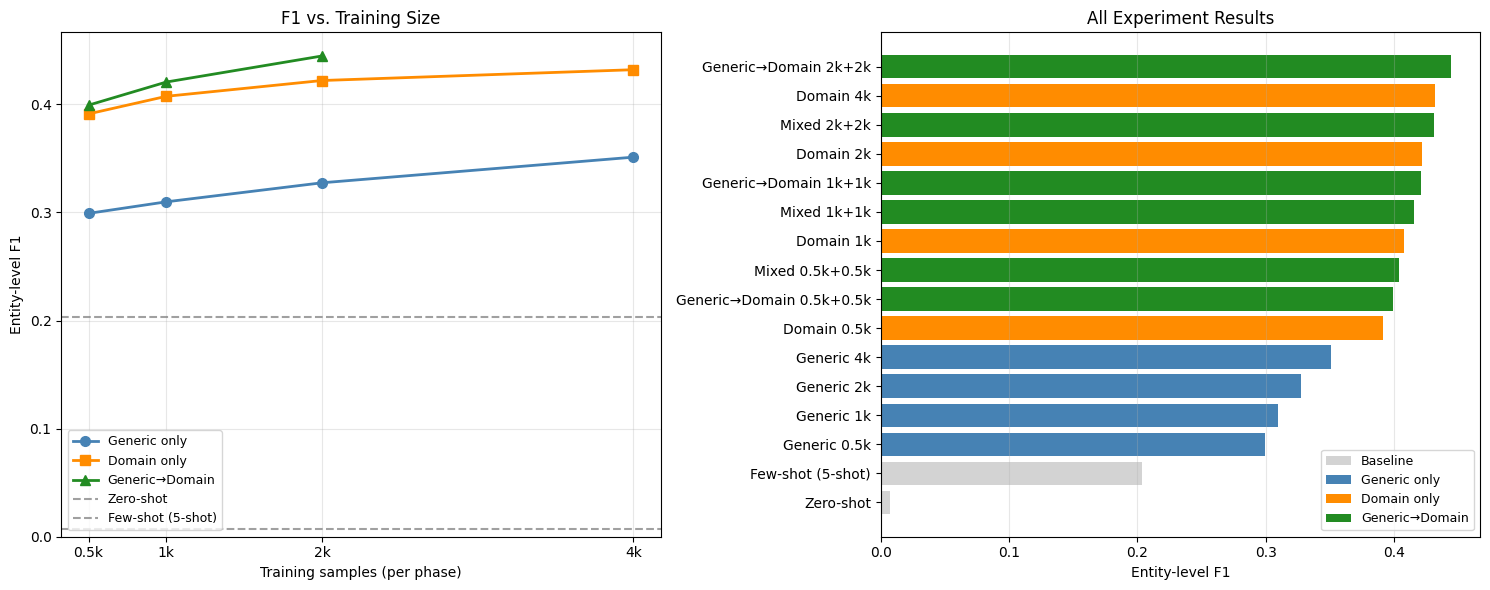

Plot saved → results_qwen25_7b.png


In [17]:
# ── Plot results ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

results = pd.read_csv(RESULTS_CSV)

baselines = results[results["experiment"].isin(["zero_shot", "few_shot"])]
generic   = results[results["experiment"].str.startswith("generic_")].sort_values("generic_n")
domain    = results[results["experiment"].str.startswith("domain_")].sort_values("domain_n")
seq       = results[results["experiment"].str.startswith("seq_")].sort_values("generic_n")

sizes = [500, 1000, 2000, 4000]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ── Left: F1 vs. training set size ───────────────────────────────────────────
for grp, label, color, marker, size_col in [
    (generic, "Generic only",      "steelblue",   "o", "generic_n"),
    (domain,  "Domain only",       "darkorange",  "s", "domain_n"),
    (seq,     "Generic→Domain",    "forestgreen", "^", "generic_n"),
]:
    f1s = grp["f1"].tolist()
    ax1.plot(sizes[:len(f1s)], f1s, marker=marker, label=label, color=color,
             linewidth=2, markersize=7)

for _, row in baselines.iterrows():
    ax1.axhline(row["f1"], linestyle="--", alpha=0.75,
                label=row["description"], color="gray")

ax1.set_xlabel("Training samples (per phase)")
ax1.set_ylabel("Entity-level F1")
ax1.set_title("F1 vs. Training Size")
ax1.set_xticks(sizes)
ax1.set_xticklabels(["0.5k", "1k", "2k", "4k"])
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# ── Right: bar chart of all experiments sorted by F1 ─────────────────────────
rs = results.sort_values("f1", ascending=True)
bar_colors = []
for _, row in rs.iterrows():
    if row["experiment"] in ["zero_shot", "few_shot"]:
        bar_colors.append("lightgray")
    elif row["experiment"].startswith("generic"):
        bar_colors.append("steelblue")
    elif row["experiment"].startswith("domain"):
        bar_colors.append("darkorange")
    else:
        bar_colors.append("forestgreen")

ax2.barh(rs["description"], rs["f1"], color=bar_colors)
ax2.set_xlabel("Entity-level F1")
ax2.set_title("All Experiment Results")
ax2.grid(True, axis="x", alpha=0.3)

# legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="lightgray",   label="Baseline"),
    Patch(facecolor="steelblue",   label="Generic only"),
    Patch(facecolor="darkorange",  label="Domain only"),
    Patch(facecolor="forestgreen", label="Generic→Domain"),
]
ax2.legend(handles=legend_elements, fontsize=9, loc="lower right")

plt.tight_layout()
plot_path = RESULTS_CSV.stem + ".png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Plot saved → {plot_path}")
